In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/Titanic Dataset.csv')
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [ ]:
encoder ={}

for col in df.columns:
  le = LabelEncoder()
  df[col] =le.fit_transform(df[col])
  encoder[col] =le

df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,0,1,21,0,44,0,0,187,273,43,2,11,121,308
1,0,1,23,1,6,1,2,49,270,79,2,2,121,230
2,0,0,24,0,8,1,2,49,270,79,2,27,121,230
3,0,0,25,1,45,1,2,49,270,79,2,27,53,230
4,0,0,26,0,38,1,2,49,270,79,2,27,121,230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,2,0,1291,0,22,1,0,259,111,186,0,27,120,369
1305,2,0,1292,0,98,1,0,259,111,186,0,27,121,369
1306,2,0,1293,1,40,0,0,250,18,186,0,27,111,369
1307,2,0,1294,1,41,0,0,264,18,186,0,27,121,369


In [ ]:
X = df.drop('survived',axis=1)
Y = df['survived']

In [ ]:
print("Features")
print(X)

Features
      pclass  name  sex  age  sibsp  ...  cabin  embarked  boat  body  home.dest
0          0    21    0   44      0  ...     43         2    11   121        308
1          0    23    1    6      1  ...     79         2     2   121        230
2          0    24    0    8      1  ...     79         2    27   121        230
3          0    25    1   45      1  ...     79         2    27    53        230
4          0    26    0   38      1  ...     79         2    27   121        230
...      ...   ...  ...  ...    ...  ...    ...       ...   ...   ...        ...
1304       2  1291    0   22      1  ...    186         0    27   120        369
1305       2  1292    0   98      1  ...    186         0    27   121        369
1306       2  1293    1   40      0  ...    186         0    27   111        369
1307       2  1294    1   41      0  ...    186         0    27   121        369
1308       2  1295    1   44      0  ...    186         2    27   121        369

[1309 rows x 13 co

In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

In [ ]:
model.fit(X,Y)
print("model Trained Successfully")

model Trained Successfully


In [ ]:
importance = model.feature_importances_
for feature, score in zip(X.columns, importance):
    print(feature, ":" ,score)

pclass : 0.0
name : 0.02416549451701878
sex : 0.038324798424137406
age : 0.012856056250687973
sibsp : 0.00660413961495485
parch : 0.010756436209267733
ticket : 0.030032145989632233
fare : 0.02453355704886773
cabin : 0.0
embarked : 0.003289113467124237
boat : 0.8450525051846538
body : 0.0
home.dest : 0.00438575329365532


In [ ]:
new_data =pd.DataFrame({
    'pclass':[0],
    'name':[21],
    'sex':[0],
    'age':[44],
    'sibsp':[0],
    'parch':[0],
    'ticket':[187],
    'fare':[273],
    'cabin':[43],
    'embarked':[2],
    'boat':[11],
    'body':[121],
    'home.dest':[308]
})

In [ ]:
prediction = model.predict(new_data)

result = encoder['survived'].inverse_transform(prediction)

print("Prediction=", result[0])

Prediction= 1


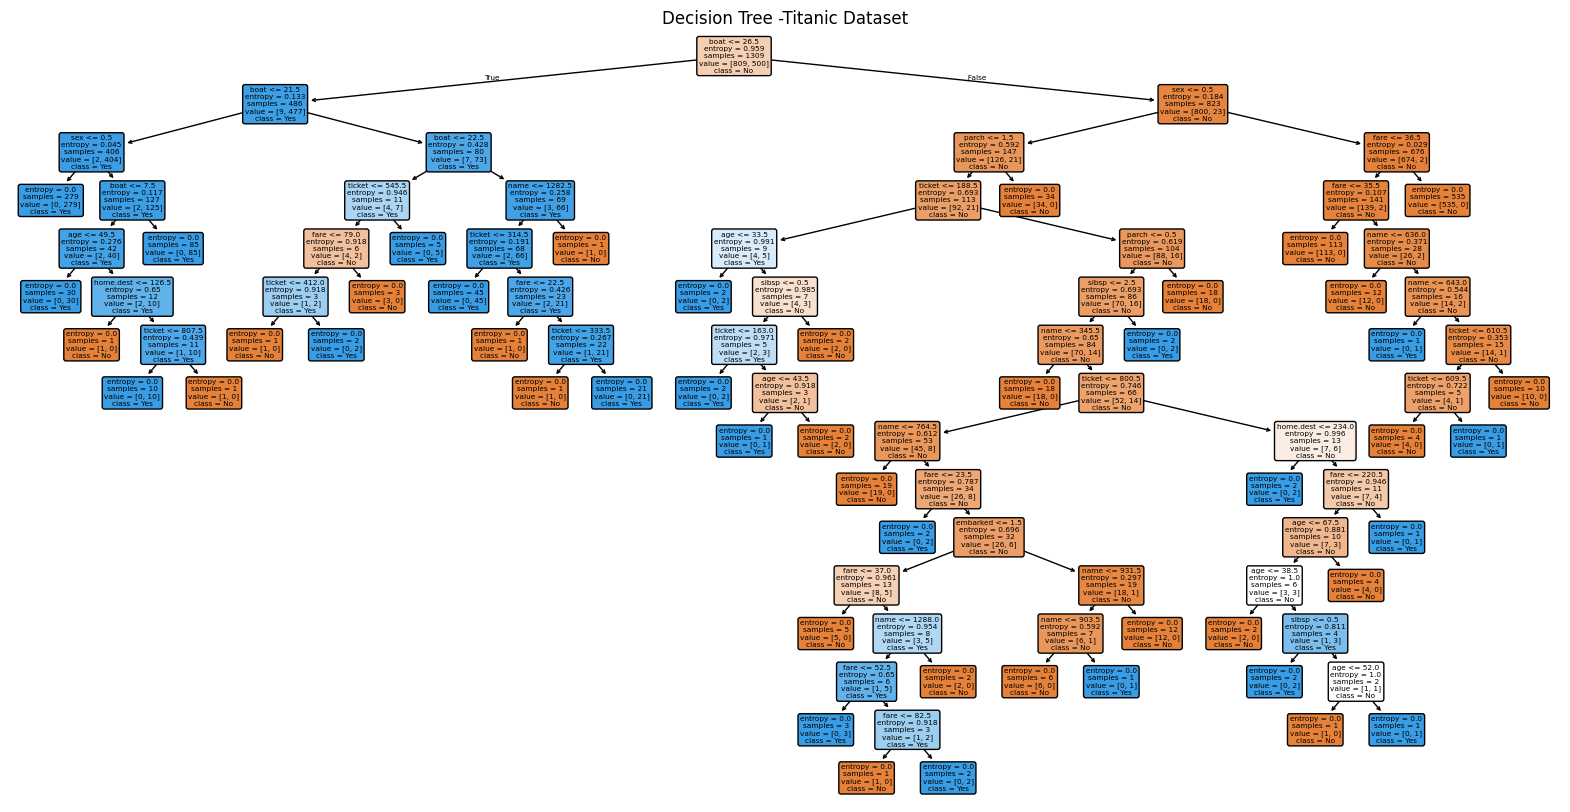

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree -Titanic Dataset")

plt.show()

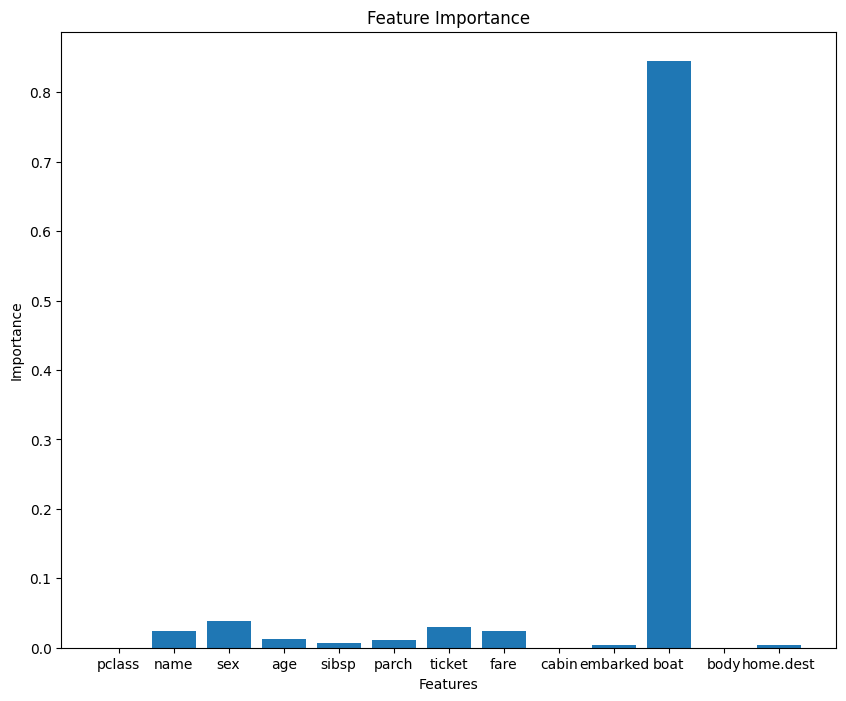

In [ ]:
plt.figure(figsize=(10,8))

plt.bar(
    X.columns,
    model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

Y_pred = model.predict(X)

accuracy = accuracy_score(Y,Y_pred)

print("Accuracy=", accuracy*100,"%")

Accuracy= 100.0 %
